<a href="https://colab.research.google.com/github/waymaker55/ehijeleabhulimhen.github.io./blob/main/newcode1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Loaded Successfully.
            Arrivals    GDP    CPI  EUR_USD  EUR_GBP
Date                                                
2010-01-01    574830  43000   99.5     1.44     0.88
2010-02-01    543531  43000   99.6     1.36     0.87
2010-03-01    643989  43000  100.0     1.35     0.90
2010-04-01    845185  43500  100.2     1.33     0.87
2010-05-01   1011505  43500  100.1     1.24     0.85

Feature Engineering Complete.
Features: ['Arrivals', 'GDP', 'CPI', 'EUR_USD', 'EUR_GBP', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'month_sin', 'month_cos']

Target Variable Created. Class Distribution:
Demand_Level
Low         42
Shoulder    42
High        42
Peak        42
Name: count, dtype: int64

Training set size: 117
Test set size: 51

--- SVC Performance (Scaled) ---
              precision    recall  f1-score   support

        High       0.20      0.25      0.22        12
         Low       0.56      1.00      0.71        15
        Peak       1.00      0.14      0.25        21
    Shoulder

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [20:03:52] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


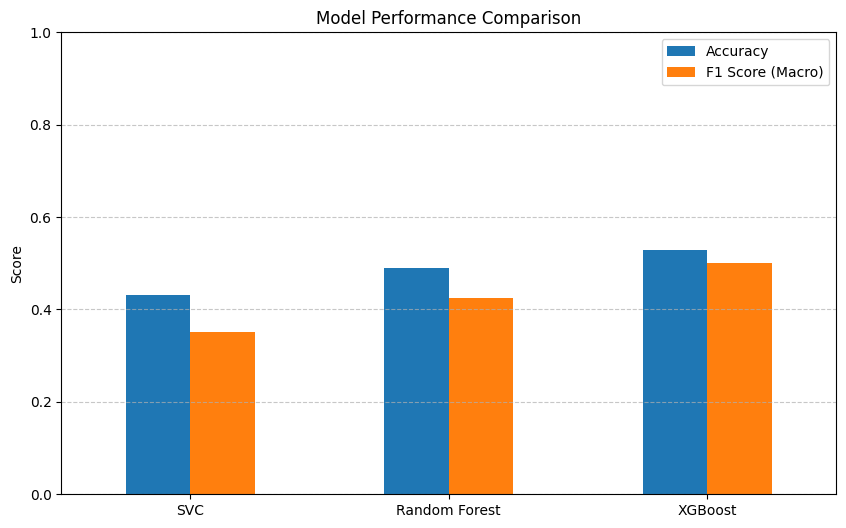

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# ==========================================
# 1. DATA LOADING (REAL DATA)
# ==========================================
# Load the provided CSV file
file_path = '/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv'
df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')

# Select only the required columns as per instructions
df = df[['Arrivals', 'GDP', 'CPI', 'EUR_USD', 'EUR_GBP']]

print("Data Loaded Successfully.")
print(df.head())

# ==========================================
# 2. FEATURE ENGINEERING
# ==========================================

# 2.1 Create Lags: 1, 2, 3, and 12 (Matching the PDF)
# Note: Lag 12 is crucial for capturing annual seasonality
lags = [1, 2, 3, 12]
for lag in lags:
    df[f'lag_{lag}'] = df['Arrivals'].shift(lag)

# 2.2 Seasonality: Month Sine and Cosine
# This allows the model to understand that December (12) is close to January (1)
df['month_num'] = df.index.month
df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)

# Drop the temporary numeric month column (optional, but cleaner)
df.drop(columns=['month_num'], inplace=True)

# 2.3 Handling Missing Data
# Lags introduce NaNs at the beginning of the dataset. We must drop them.
df.dropna(inplace=True)

print("\nFeature Engineering Complete.")
print(f"Features: {df.columns.tolist()}")

# ==========================================
# 3. TARGET CREATION (BINNING)
# ==========================================
# Create Classification Targets based on Quantiles (Equal-Frequency Binning)
# Labels: 'Low', 'Shoulder', 'High', 'Peak'

# Define labels
labels = ['Low', 'Shoulder', 'High', 'Peak']

# Create the bins using qcut (Quantile Cut)
df['Demand_Level'] = pd.qcut(df['Arrivals'], q=4, labels=labels)

print("\nTarget Variable Created. Class Distribution:")
print(df['Demand_Level'].value_counts())

# ==========================================
# 4. PREPARING FOR MODELING
# ==========================================

# Separate Features (X) and Target (y)
X = df.drop(columns=['Arrivals', 'Demand_Level'])
y = df['Demand_Level']

# Encode Target Labels for XGBoost (It requires integers 0, 1, 2, 3)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split Data: 70% Train, 30% Test (Chronological Split)
# We do not shuffle because this is time-series data
train_size = int(len(df) * 0.7)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y_encoded[:train_size], y_encoded[train_size:]

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# ==========================================
# 5. MODELING
# ==========================================

# Dictionary to store results
results = {}

# ------------------------------------------
# Model 1: Support Vector Classifier (SVC) - FIXED
# ------------------------------------------
# The fix: Using a Pipeline with StandardScaler to scale features before SVC.
# SVC is distance-based and fails without scaling on data like GDP (40k+) vs CPI (100).

svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_test)

results['SVC'] = {
    'Accuracy': accuracy_score(y_test, y_pred_svc),
    'F1 Score (Macro)': f1_score(y_test, y_pred_svc, average='macro')
}

print("\n--- SVC Performance (Scaled) ---")
print(classification_report(y_test, y_pred_svc, target_names=le.classes_))

# ------------------------------------------
# Model 2: Random Forest Classifier
# ------------------------------------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

results['Random Forest'] = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'F1 Score (Macro)': f1_score(y_test, y_pred_rf, average='macro')
}

print("\n--- Random Forest Performance ---")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

# ------------------------------------------
# Model 3: XGBoost Classifier
# ------------------------------------------
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

results['XGBoost'] = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'F1 Score (Macro)': f1_score(y_test, y_pred_xgb, average='macro')
}

print("\n--- XGBoost Performance ---")
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

# ==========================================
# 6. FINAL COMPARISON
# ==========================================
print("\n=== Model Comparison Table ===")
results_df = pd.DataFrame(results).T
print(results_df)

# Plotting the comparison
results_df.plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()